In [2]:
# =============================
# IMPORTS
# =============================

# Core libraries
import numpy as np
import pandas as pd

# Statistics & econometrics
import scipy
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.tools import add_constant
from linearmodels.iv import AbsorbingLS
from linearmodels.iv import IV2SLS

# Machine learning
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, cross_validate, cross_val_predict
)
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import xgboost as xgb
from sklearn.linear_model    import RidgeCV
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import r2_score, mean_squared_error
from sklearn.inspection      import permutation_importance
from scipy.stats             import spearmanr, ttest_rel, wilcoxon

# Network analysis
import networkx as nx

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("All packages imported successfully!\n")

# Core
print(f"numpy:           {np.__version__}")
print(f"pandas:          {pd.__version__}")

# Statistics / Econometrics
import statsmodels
import linearmodels
print(f"statsmodels:     {statsmodels.__version__}")
print(f"linearmodels:    {linearmodels.__version__}")
print(f"scipy:           {scipy.__version__}")

# Machine Learning
import sklearn
print(f"sklearn:         {sklearn.__version__}")
print(f"xgboost:         {xgb.__version__}")

# Network Analysis
print(f"networkx:        {nx.__version__}")

# Visualization
import matplotlib
import seaborn
print(f"matplotlib:      {matplotlib.__version__}")
print(f"seaborn:         {seaborn.__version__}")

All packages imported successfully!

numpy:           2.1.3
pandas:          2.2.3
statsmodels:     0.14.4
linearmodels:    7.0
scipy:           1.15.3
sklearn:         1.6.1
xgboost:         3.2.0
networkx:        3.4.2
matplotlib:      3.10.0
seaborn:         0.13.2


In [3]:
np.random.seed(42)

## Figure 1

Gossip villages : 71
Elder  villages : 71
Random villages : 70

Mean calls by arm:
  Gossip : 12.70
  Random : 8.44
  Elder  : 5.52


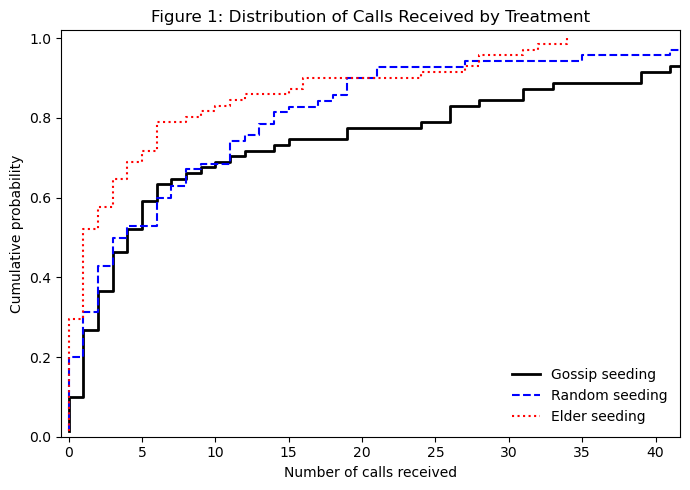

In [12]:
# =========================================================
# FIGURE 1: CDF OF CALLS RECEIVED BY TREATMENT
# =========================================================

# Subset by treatment arm
df_gossip = df[df['gossip'] == 1]
df_elder  = df[df['elder']  == 1]
df_random = df[df['random'] == 1]

print(f"Gossip villages : {len(df_gossip)}")
print(f"Elder  villages : {len(df_elder)}")
print(f"Random villages : {len(df_random)}")

print("\nMean calls by arm:")
print(f"  Gossip : {df_gossip['CallsReceived'].mean():.2f}")
print(f"  Random : {df_random['CallsReceived'].mean():.2f}")
print(f"  Elder  : {df_elder ['CallsReceived'].mean():.2f}")


# ---------------------------------------------------------
# Helper: empirical CDF
# ---------------------------------------------------------
def ecdf(series):
    x = np.sort(series.dropna().values)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

arms = [
    ('Gossip seeding', df_gossip['CallsReceived'], 'black', '-', 2.0),
    ('Random seeding', df_random['CallsReceived'], 'blue',  '--', 1.5),
    ('Elder seeding',  df_elder ['CallsReceived'], 'red',   ':',  1.5),
]

for label, series, color, ls, lw in arms:
    x, y = ecdf(series)
    ax.step(x, y, where='post', color=color, linestyle=ls,
            linewidth=lw, label=label)


# Axis limits (trim extreme tail for readability)
x_max = np.percentile(df['CallsReceived'].dropna(), 97)
ax.set_xlim(-0.5, max(x_max, 40))
ax.set_ylim(0, 1.02)


# Labels and title
ax.set_xlabel("Number of calls received")
ax.set_ylabel("Cumulative probability")
ax.set_title("Figure 1: Distribution of Calls Received by Treatment")


# Legend
ax.legend(frameon=False, loc='lower right')


# Save and display
plt.tight_layout()
plt.savefig("Figure1_CDF_calls.png", dpi=300)
plt.show()

## Table 1

In [7]:
# =============================
# KARNATAKA RCT: LOAD DATA
# =============================

df_karn = pd.read_stata("karnataka_cell_rct.dta")

# Basic checks
print(f"Observations: {df_karn.shape[0]}, Variables: {df_karn.shape[1]}")

# Inspect variables (useful for mapping to paper)
print("\nVariables:")
print(df_karn.columns.tolist())

Observations: 213, Variables: 22

Variables:
['villageid', 'num_hh_random', 'NumberofSeeds', 'CallsReceived', 'num_seeds', 'flyer', 'inj', 'gossip', 'random', 'elder', 'NormalizedCalls_Ex', 'atleast_gossip_1', 'atleast_elder_1', 'dcAtleast1', 'flierVillage', 'gossip_ct', 'elder_ct', 'gossip_miss', 'elder_miss', 'both_miss', 'gossip5', 'elder5']


In [11]:
# =========================================================
# TABLE 1: KARNATAKA RCT RESULTS
# =========================================================

# Drop broadcast/flier village
df = df_karn[df_karn['flierVillage'] != 1].copy()
print(f"Sample size after dropping flier village: {len(df)}")


# =========================================================
# PANEL A: TOTAL CALLS RECEIVED
# =========================================================

print("\n================ PANEL A: TOTAL CALLS ================\n")

# Column 1: Reduced Form
model_rf = smf.ols(
    'CallsReceived ~ gossip + elder + num_seeds + gossip_ct + elder_ct',
    data=df
).fit(cov_type='HC1')

print("Column 1: Reduced Form")
print(model_rf.summary2().tables[1][['Coef.', 'Std.Err.']])

control_mean = df.loc[df['random'] == 1, 'CallsReceived'].mean()
print(f"\nControl mean (random villages): {control_mean:.3f}")


# Column 2: OLS
model_ols = smf.ols(
    'CallsReceived ~ atleast_gossip_1 + atleast_elder_1 + num_seeds + gossip_ct + elder_ct',
    data=df
).fit(cov_type='HC1')

print("\nColumn 2: OLS")
print(model_ols.summary2().tables[1][['Coef.', 'Std.Err.']])


# Columns 3 & 4: First Stage
fs_gossip = smf.ols(
    'atleast_gossip_1 ~ gossip + elder + num_seeds + gossip_ct + elder_ct',
    data=df
).fit(cov_type='HC1')

fs_elder = smf.ols(
    'atleast_elder_1 ~ gossip + elder + num_seeds + gossip_ct + elder_ct',
    data=df
).fit(cov_type='HC1')

print("\nColumn 3: First Stage (Gossip)")
print(fs_gossip.summary2().tables[1][['Coef.', 'Std.Err.']])

print("\nColumn 4: First Stage (Elder)")
print(fs_elder.summary2().tables[1][['Coef.', 'Std.Err.']])


# Column 5: IV
df['const'] = 1

iv_model = IV2SLS(
    dependent=df['CallsReceived'],
    exog=df[['const', 'num_seeds', 'gossip_ct', 'elder_ct']],
    endog=df[['atleast_gossip_1', 'atleast_elder_1']],
    instruments=df[['gossip', 'elder']]
).fit(cov_type='robust')

print("\nColumn 5: IV")
print(iv_model.summary.tables[1])


# =========================================================
# PANEL B: NORMALIZED CALLS (CALLS PER SEED)
# =========================================================

print("\n\n================ PANEL B: CALLS PER SEED ================\n")

# Column 1: Reduced Form
model_rf_b = smf.ols(
    'NormalizedCalls_Ex ~ gossip + elder + num_seeds + gossip_ct + elder_ct',
    data=df
).fit(cov_type='HC1')

print("Column 1: Reduced Form")
print(model_rf_b.summary2().tables[1][['Coef.', 'Std.Err.']])


# Column 2: OLS
model_ols_b = smf.ols(
    'NormalizedCalls_Ex ~ atleast_gossip_1 + atleast_elder_1 + num_seeds + gossip_ct + elder_ct',
    data=df
).fit(cov_type='HC1')

print("\nColumn 2: OLS")
print(model_ols_b.summary2().tables[1][['Coef.', 'Std.Err.']])


# Columns 3 & 4: First Stage (same as Panel A, re-estimated for clarity)
fs_gossip_b = smf.ols(
    'atleast_gossip_1 ~ gossip + elder + num_seeds + gossip_ct + elder_ct',
    data=df
).fit(cov_type='HC1')

fs_elder_b = smf.ols(
    'atleast_elder_1 ~ gossip + elder + num_seeds + gossip_ct + elder_ct',
    data=df
).fit(cov_type='HC1')

print("\nColumn 3: First Stage (Gossip)")
print(fs_gossip_b.summary2().tables[1][['Coef.', 'Std.Err.']])

print("\nColumn 4: First Stage (Elder)")
print(fs_elder_b.summary2().tables[1][['Coef.', 'Std.Err.']])


# Column 5: IV
iv_model_b = IV2SLS(
    dependent=df['NormalizedCalls_Ex'],
    exog=df[['const', 'num_seeds', 'gossip_ct', 'elder_ct']],
    endog=df[['atleast_gossip_1', 'atleast_elder_1']],
    instruments=df[['gossip', 'elder']]
).fit(cov_type='robust')

print("\nColumn 5: IV")
print(iv_model_b.summary.tables[1])

Sample size after dropping flier village: 212

================ PANEL A: TOTAL CALLS ================

Column 1: Reduced Form
              Coef.  Std.Err.
Intercept -1.162222  4.531769
gossip     3.593839  2.612923
elder     -2.009723  1.872812
num_seeds  1.118071  0.951762
gossip_ct -0.111916  0.178199
elder_ct   0.896347  0.377835

Control mean (random villages): 8.443

Column 2: OLS
                     Coef.  Std.Err.
Intercept        -1.925433  4.452546
atleast_gossip_1  4.067788  1.789964
atleast_elder_1   0.253896  1.876376
num_seeds         0.789884  0.940258
gossip_ct        -0.305339  0.191530
elder_ct          1.080416  0.398477

Column 3: First Stage (Gossip)
              Coef.  Std.Err.
Intercept -0.195607  0.115898
gossip     0.679132  0.057921
elder      0.233015  0.075071
num_seeds  0.068650  0.025823
gossip_ct  0.043503  0.005607
elder_ct  -0.007236  0.008028

Column 4: First Stage (Elder)
              Coef.  Std.Err.
Intercept  0.080916  0.110997
gossip     0.30606

## Figure 2

Running Panel A quantile regressions...
Running Panel B quantile regressions...


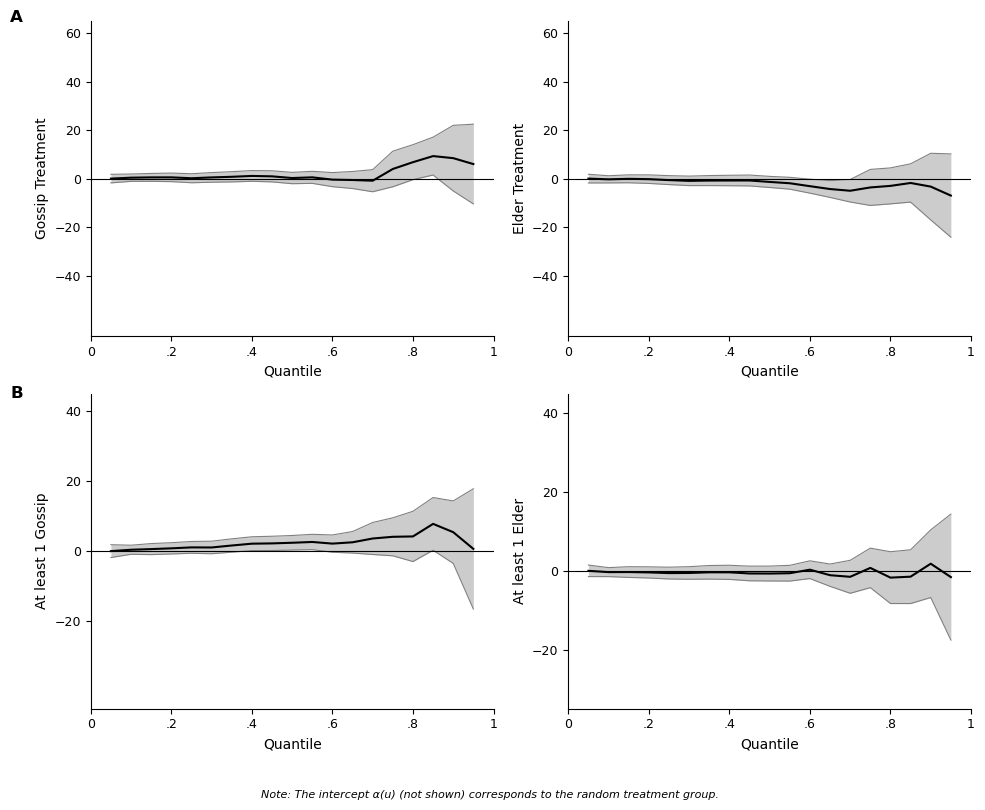

Figure 2 saved as Figure2_QuantileEffects.png


In [15]:
# =========================================================
# FIGURE 2: QUANTILE TREATMENT EFFECTS
# =========================================================

# Quantiles
quantiles = np.arange(0.05, 1.0, 0.05)


# ---------------------------------------------------------
# Helper: quantile regression + confidence intervals
# ---------------------------------------------------------
def get_qte(formula, var, data, quantiles):
    coefs, lower, upper = [], [], []

    for q in quantiles:
        qr = smf.quantreg(formula, data=data).fit(q=q, max_iter=2000)

        c  = qr.params.get(var, np.nan)
        ci = qr.conf_int().loc[var] if var in qr.params else [np.nan, np.nan]

        coefs.append(c)
        lower.append(ci[0])
        upper.append(ci[1])

    return np.array(coefs), np.array(lower), np.array(upper)


# ---------------------------------------------------------
# PANEL A: Reduced Form
# ---------------------------------------------------------
formula_a = 'CallsReceived ~ gossip + elder + num_seeds + gossip_ct + elder_ct'

print("Running Panel A quantile regressions...")
gossip_a, gossip_a_lo, gossip_a_hi = get_qte(formula_a, 'gossip', df, quantiles)
elder_a,  elder_a_lo,  elder_a_hi  = get_qte(formula_a, 'elder',  df, quantiles)


# ---------------------------------------------------------
# PANEL B: At least one gossip/elder reached
# ---------------------------------------------------------
formula_b = 'CallsReceived ~ atleast_gossip_1 + atleast_elder_1 + num_seeds + gossip_ct + elder_ct'

print("Running Panel B quantile regressions...")
gossip_b, gossip_b_lo, gossip_b_hi = get_qte(formula_b, 'atleast_gossip_1', df, quantiles)
elder_b,  elder_b_lo,  elder_b_hi  = get_qte(formula_b, 'atleast_elder_1', df, quantiles)


# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

line_color = 'black'
ci_color   = 'grey'
lw = 1.5


def plot_qte(ax, quantiles, coefs, lower, upper, ylabel):
    ax.fill_between(quantiles, lower, upper, color=ci_color, alpha=0.4, linewidth=0)
    ax.plot(quantiles, upper, color=ci_color, linewidth=0.8)
    ax.plot(quantiles, lower, color=ci_color, linewidth=0.8)
    ax.plot(quantiles, coefs, color=line_color, linewidth=lw)

    ax.axhline(0, color='black', linewidth=0.8)

    ax.set_xlabel('Quantile', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlim(0, 1)

    ax.tick_params(labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ---------------------------------------------------------
# PANEL A (Top Row)
# ---------------------------------------------------------
fig.text(0.02, 0.95, 'A', fontsize=12, fontweight='bold')

plot_qte(axes[0, 0], quantiles, gossip_a, gossip_a_lo, gossip_a_hi, 'Gossip Treatment')
plot_qte(axes[0, 1], quantiles, elder_a,  elder_a_lo,  elder_a_hi,  'Elder Treatment')

# Match paper scale
axes[0, 0].set_ylim(-65, 65)
axes[0, 1].set_ylim(-65, 65)

for ax in axes[0]:
    ax.set_yticks([-40, -20, 0, 20, 40, 60])


# ---------------------------------------------------------
# PANEL B (Bottom Row)
# ---------------------------------------------------------
fig.text(0.02, 0.48, 'B', fontsize=12, fontweight='bold')

plot_qte(axes[1, 0], quantiles, gossip_b, gossip_b_lo, gossip_b_hi, 'At least 1 Gossip')
plot_qte(axes[1, 1], quantiles, elder_b,  elder_b_lo,  elder_b_hi,  'At least 1 Elder')

axes[1, 0].set_ylim(-45, 45)
axes[1, 1].set_ylim(-35, 45)

for ax in axes[1]:
    ax.set_yticks([-20, 0, 20, 40])


# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------
for ax in axes.flat:
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xticklabels(['0', '.2', '.4', '.6', '.8', '1'])

fig.text(
    0.5, -0.02,
    'Note: The intercept α(u) (not shown) corresponds to the random treatment group.',
    ha='center', fontsize=8, style='italic'
)

plt.tight_layout(rect=[0.03, 0.02, 1, 0.97])
plt.savefig('Figure2_QuantileEffects.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 2 saved as Figure2_QuantileEffects.png")

## Table 2

In [13]:
# =========================================================
# HARYANA RCT: LOAD DATA
# =========================================================

df_seeds   = pd.read_stata("haryana_rct_Table2_seedslevel.dta")
df_village = pd.read_stata("haryana_rct_Table2_villagelevel.dta")

# Basic checks
print(f"Seed-level data:    {df_seeds.shape[0]} observations, {df_seeds.shape[1]} variables")
print(f"Village-level data: {df_village.shape[0]} observations, {df_village.shape[1]} variables")

# Variable lists (useful for mapping to paper tables)
print("\nSeed-level variables:")
print(df_seeds.columns.tolist())

print("\nVillage-level variables:")
print(df_village.columns.tolist())

Seed-level data:    2604 observations, 25 variables
Village-level data: 397 observations, 4 variables

Seed-level variables:
['id_seed', 'id_district', 'id_phc', 'id_sc', 'id_village', 'id_village_unit', 'commtreat_arm', 'refused', 'seedage', 'female', 'education', 'ownland', 'landarea', 'asset_index', 'hindu', 'muslim', 'caste_stsc', 'caste_obc', 'member_panchayat', 'num_or_chauk', 'interact_1', 'parti_1', 'f7_aware_immu_camp_1', 'f1_anm_aware_1', 'f4_aware_asha_1']

Village-level variables:
['id_village', 'nomstop6', 'commtreat_arm', 'nnoms_byvillage']


In [14]:
# =========================================================
# TABLE 2: SUMMARY STATISTICS (HARYANA RCT)
# =========================================================

# Treatment arms (paper order)
arms = ['Random', 'Gossip', 'Trusted', 'Trusted Gossip']


# =========================================================
# PANEL A: NOMINATION STATISTICS (Village Level)
# =========================================================

print("\n" + "=" * 70)
print("TABLE 2 - PANEL A: NOMINATION STATISTICS")
print("=" * 70)

nom_vars = {
    'Number of nominations (per village)': 'nnoms_byvillage',
    'Nominations for top 6 individuals':   'nomstop6',
}

for label, var in nom_vars.items():
    print(f"\n{label}")
    for arm in [a for a in arms if a != 'Random']:  # Random has no nominations
        sub = df_village[df_village['commtreat_arm'] == arm][var].dropna()
        print(f"  {arm:20s}  {sub.mean():6.3f} ({sub.std():.3f})")


# =========================================================
# PANEL B: SEED CHARACTERISTICS (Seed Level)
# =========================================================

print("\n" + "=" * 70)
print("TABLE 2 - PANEL B: SEED CHARACTERISTICS")
print("=" * 70)

char_vars = {
    'Refused to participate':      'refused',
    'Age':                         'seedage',
    'Female':                      'female',
    'Education (years)':           'education',
    'Owns land':                   'ownland',
    'Wealth index':                'asset_index',
    'Hindu':                       'hindu',
    'Muslim':                      'muslim',
    'SC/ST':                       'caste_stsc',
    'OBC':                         'caste_obc',
    'Panchayat member':            'member_panchayat',
    'Numberdaar/Chaukidaar':       'num_or_chauk',
    'Interacts very often':        'interact_1',
    'Participates very often':     'parti_1',
    'Aware of immunization camps': 'f7_aware_immu_camp_1',
    'Aware of ANMs':               'f1_anm_aware_1',
    'Aware of ASHAs':              'f4_aware_asha_1',
}

rows = []
for label, var in char_vars.items():
    row = {'Variable': label}
    for arm in arms:
        sub = df_seeds[df_seeds['commtreat_arm'] == arm][var].dropna()
        row[f'{arm}_mean'] = sub.mean()
        row[f'{arm}_sd']   = sub.std()
    rows.append(row)

df_table2 = pd.DataFrame(rows)


# Print formatted table
print(f"\n{'Variable':<40} {'Random':>15} {'Gossip':>15} {'Trusted':>15} {'T.Gossip':>15}")
print("-" * 100)

for _, r in df_table2.iterrows():
    print(f"{r['Variable']:<40} "
          f"{r['Random_mean']:>6.3f} ({r['Random_sd']:.3f})   "
          f"{r['Gossip_mean']:>6.3f} ({r['Gossip_sd']:.3f})   "
          f"{r['Trusted_mean']:>6.3f} ({r['Trusted_sd']:.3f})   "
          f"{r['Trusted Gossip_mean']:>6.3f} ({r['Trusted Gossip_sd']:.3f})")


# =========================================================
# OBSERVATION COUNTS
# =========================================================

print("\nObservations per treatment arm:")
print(df_seeds.groupby('commtreat_arm').size())


# =========================================================
# BALANCE TESTS (ANOVA)
# =========================================================

print("\n" + "=" * 70)
print("BALANCE TESTS (ANOVA ACROSS ARMS)")
print("=" * 70)

for label, var in char_vars.items():
    groups = [df_seeds[df_seeds['commtreat_arm'] == arm][var].dropna() for arm in arms]
    f_stat, p_val = stats.f_oneway(*groups)

    sig = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""
    print(f"{label:<40}  F = {f_stat:6.3f}   p = {p_val:.3f}   {sig}")


TABLE 2 - PANEL A: NOMINATION STATISTICS

Number of nominations (per village)
  Gossip                19.915 (8.585)
  Trusted               20.313 (8.670)
  Trusted Gossip        19.993 (11.351)

Nominations for top 6 individuals
  Gossip                11.217 (4.576)
  Trusted               10.560 (4.265)
  Trusted Gossip        10.769 (5.575)

TABLE 2 - PANEL B: SEED CHARACTERISTICS

Variable                                          Random          Gossip         Trusted        T.Gossip
----------------------------------------------------------------------------------------------------
Refused to participate                    0.186 (0.389)    0.165 (0.372)    0.219 (0.414)    0.175 (0.380)
Age                                      49.233 (14.617)   48.569 (14.347)   52.040 (14.130)   48.890 (14.082)
Female                                    0.054 (0.227)    0.108 (0.311)    0.055 (0.228)    0.098 (0.297)
Education (years)                         6.980 (4.280)    8.499 (3.966)    8.

## Table 3

In [17]:
# =========================================================
# TABLE 3: HARYANA RCT – LOAD DATA
# =========================================================

df_t3 = pd.read_csv("haryana_rct_Table3.csv")

# Basic checks
print(f"Observations: {df_t3.shape[0]}, Variables: {df_t3.shape[1]}")

# Variable list (important for regression mapping)
print("\nVariables:")
print(df_t3.columns.tolist())

Observations: 6712, Variables: 20

Variables:
['id_phc', 'gossip', 'trusted', 'trustgossip', 'random', 'highslope', 'highflat', 'lowslope', 'lowflat', 'id_village_grp', 'district', 'created_year', 'created_month', 'shot_Penta1', 'shot_Penta2', 'shot_Penta3', 'shot_Measles1', 'nchildren', 'SMS33', 'SMS66']


In [19]:
# ---------------------------------------------------------
# Sample restriction (Feb 2017 – Mar 2018)
# ---------------------------------------------------------
df = df_t3[
    (df_t3['created_year'] == 2017) |
    ((df_t3['created_year'] == 2018) & (df_t3['created_month'] <= 3))
].copy()

print(f"Sample size after restriction: {df.shape}")


# ---------------------------------------------------------
# Fixed effects: district × month (year-month)
# ---------------------------------------------------------
df['dist_month'] = (
    df['district'].astype(str) + '_' +
    df['created_year'].astype(str) + '_' +
    df['created_month'].astype(str)
)

dist_month_dummies = pd.get_dummies(df['dist_month'], drop_first=True)


# ---------------------------------------------------------
# Outcomes (as in paper)
# ---------------------------------------------------------
outcomes = {
    'Penta1':   'shot_Penta1',
    'Penta2':   'shot_Penta2',
    'Penta3':   'shot_Penta3',
    'Measles':  'shot_Measles1',
    'Any shot': 'nchildren',
}


# ---------------------------------------------------------
# Regression function
# ---------------------------------------------------------
def run_models(extra_vars=None):
    if extra_vars is None:
        extra_vars = []

    X = pd.concat([
        df[['gossip', 'trusted', 'trustgossip',
            'highslope', 'lowslope', 'highflat', 'lowflat'] + extra_vars],
        dist_month_dummies
    ], axis=1).astype(float)

    X = sm.add_constant(X)

    results = {}

    for name, var in outcomes.items():
        y = df[var].dropna()
        X_sub = X.loc[y.index]

        results[name] = sm.OLS(y, X_sub).fit(
            cov_type='cluster',
            cov_kwds={'groups': df.loc[y.index, 'id_village_grp']}
        )

    return results


# ---------------------------------------------------------
# P-value helper
# ---------------------------------------------------------
def p_test(res, v1, v2=None):
    if v2 is None:
        return res.pvalues[v1]

    diff = res.params[v1] - res.params[v2]
    se = np.sqrt(
        res.cov_params().loc[v1, v1] +
        res.cov_params().loc[v2, v2] -
        2 * res.cov_params().loc[v1, v2]
    )

    return 2 * (1 - stats.t.cdf(abs(diff / se), df=res.df_resid))


# ---------------------------------------------------------
# Table printer
# ---------------------------------------------------------
def print_table(results, title, treatment_rows, pval_rows):
    cols = list(outcomes.keys())
    w = 12

    print("\n" + "=" * 85)
    print(f"TABLE 3 — {title}")
    print("=" * 85)

    print(f"\n{'':32}" + "".join(f"{c:>{w}}" for c in cols))
    print("-" * 95)

    # Coefficients + SE
    for coef, label in treatment_rows:
        coef_line = "".join(f"{results[c].params[coef]:>{w}.3f}" for c in cols)
        se_line   = "".join(f"({results[c].bse[coef]:.3f})".rjust(w) for c in cols)

        print(f"{label:<32}{coef_line}")
        print(f"{'':32}{se_line}")

    # Observations
    print(f"\n{'Observations':32}" +
          "".join(f"{results[c].nobs:>{w}.0f}" for c in cols))

    # Villages (constant in paper)
    print(f"{'Villages':32}" +
          "".join(f"{'521':>{w}}" for _ in cols))

    # Control mean
    print(f"{'Mean (Random seeds)':32}" +
          "".join(f"{df[df['random']==1][outcomes[c]].mean():>{w}.2f}"
                  for c in cols))

    # P-values
    print()
    for label, v1, v2 in pval_rows:
        line = "".join(f"{p_test(results[c], v1, v2):>{w}.3f}" for c in cols)
        print(f"{label:<32}{line}")


# =========================================================
# PANEL A: WITHOUT SMS
# =========================================================

res_a = run_models()

treatment_rows_a = [
    ('gossip',      'Gossip'),
    ('trusted',     'Trusted'),
    ('trustgossip', 'Trusted Gossip'),
]

pval_rows_a = [
    ('Gossip = Random (pval.)',         'gossip', None),
    ('Gossip = Trusted (pval.)',        'gossip', 'trusted'),
    ('Gossip = Trusted Gossip (pval.)', 'gossip', 'trustgossip'),
]

print_table(res_a, "PANEL A — Without SMS", treatment_rows_a, pval_rows_a)


# =========================================================
# PANEL B: WITH SMS
# =========================================================

res_b = run_models(extra_vars=['SMS33', 'SMS66'])

treatment_rows_b = [
    ('gossip',      'Gossip'),
    ('trusted',     'Trusted'),
    ('trustgossip', 'Trusted Gossip'),
    ('SMS33',       'SMS blast 33%'),
    ('SMS66',       'SMS blast 66%'),
]

pval_rows_b = [
    ('Gossip = SMS 33% (pval.)',        'gossip', 'SMS33'),
    ('Gossip = SMS 66% (pval.)',        'gossip', 'SMS66'),
    ('Gossip = Random (pval.)',         'gossip', None),
    ('Gossip = Trusted (pval.)',        'gossip', 'trusted'),
    ('Gossip = Trusted Gossip (pval.)', 'gossip', 'trustgossip'),
]

print_table(res_b, "PANEL B — With SMS Controls", treatment_rows_b, pval_rows_b)


# =========================================================
# COMPARISON WITH PAPER (ANY SHOT)
# =========================================================

print("\n" + "=" * 60)
print("COMPARISON WITH PAPER (Any Shot)")
print("=" * 60)

paper_a = {'Gossip': 4.903, 'Trusted': 1.849, 'Trusted Gossip': 2.376}
paper_b = {'Gossip': 5.052, 'Trusted': 1.821, 'Trusted Gossip': 2.423,
           'SMS33': 3.507,  'SMS66': 0.723}

print(f"\n{'':25} {'Paper':>10} {'Ours':>10} {'Diff':>10}")
print("-" * 55)

print("Panel A:")
for label, var in [('Gossip','gossip'), ('Trusted','trusted'), ('Trusted Gossip','trustgossip')]:
    ours  = res_a['Any shot'].params[var]
    paper = paper_a[label]
    print(f"{label:<25} {paper:>10.3f} {ours:>10.3f} {ours-paper:>+10.3f}")

print("\nPanel B:")
for label, var in [('Gossip','gossip'), ('Trusted','trusted'),
                   ('Trusted Gossip','trustgossip'),
                   ('SMS33','SMS33'), ('SMS66','SMS66')]:
    ours  = res_b['Any shot'].params[var]
    paper = paper_b[label]
    print(f"{label:<25} {paper:>10.3f} {ours:>10.3f} {ours-paper:>+10.3f}")

Sample size after restriction: (6705, 20)

TABLE 3 — PANEL A — Without SMS

                                      Penta1      Penta2      Penta3     Measles    Any shot
-----------------------------------------------------------------------------------------------
Gossip                                 1.074       0.937       0.948       1.040       4.518
                                     (0.581)     (0.545)     (0.506)     (0.491)     (2.415)
Trusted                                0.393       0.394       0.545       0.512       2.086
                                     (0.500)     (0.462)     (0.432)     (0.418)     (2.080)
Trusted Gossip                         0.637       0.615       0.638       0.593       2.904
                                     (0.493)     (0.448)     (0.416)     (0.400)     (2.009)

Observations                            6690        6690        6690        6690        6705
Villages                                 521         521         521         521   

## Figure 3

In [20]:
# =========================================================
# FIGURE 3: HARYANA RCT — LOAD DATA
# =========================================================

df_h = pd.read_csv("haryana_rct_Figure3.csv")

# Basic checks
print(f"Observations: {df_h.shape[0]}, Variables: {df_h.shape[1]}")

# Variable list (useful for plotting + regressions)
print("\nVariables:")
print(df_h.columns.tolist())

# Time structure
print("\nMonths in data:", sorted(df_h['created_month'].unique()))
print("Districts:", sorted(df_h['district'].unique()))

# Treatment counts (sanity check)
print("\nTreatment counts:")
print(df_h[['gossip', 'trusted', 'trustgossip', 'random']].sum())

Observations: 6712, Variables: 13

Variables:
['anyseed', 'baseline', 'district', 'id_village_grp', 'slope', 'flat', 'random', 'gossip', 'trusted', 'trustgossip', 'created_year', 'created_month', 'nchildren']

Months in data: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Districts: ['Bhiwani', 'Jhajjar', 'Mewat', 'Palwal', 'Panipat', 'Rewari', 'Sonipat']

Treatment counts:
gossip         1677
trusted        1701
trustgossip    1660
random         1674
dtype: int64


Gossip variation within district-month cells:
  Max unique values: 2
  Min unique values: 2
Months estimated: 12


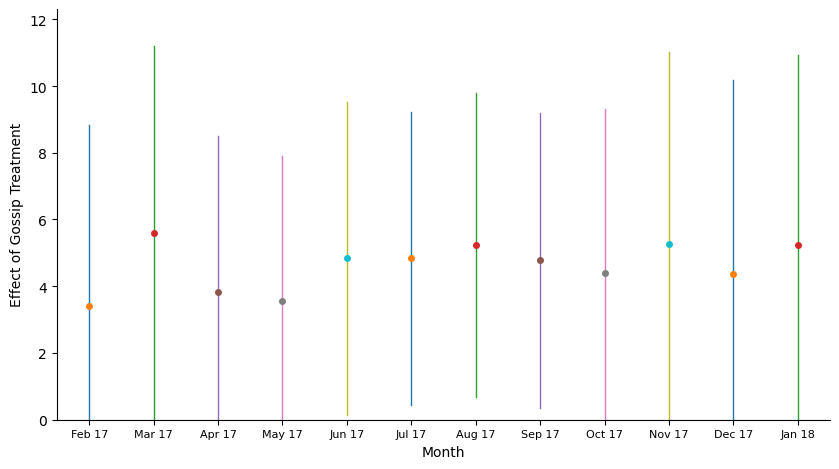

Figure 3 saved as Figure3_replicated.png


In [21]:
# =========================================================
# FIGURE 3: MONTHLY EFFECT OF GOSSIP TREATMENT
# =========================================================

# ── 1. Check variation within district-month cells ─────────
check = df_h.groupby(['district', 'created_month'])['gossip'].nunique()

print("Gossip variation within district-month cells:")
print(f"  Max unique values: {check.max()}")
print(f"  Min unique values: {check.min()}")

# ── 2. Month-by-month regressions (district FE only) ───────

months_all = sorted(df_h['created_month'].unique())

PAPER_LABELS = [
    'Feb 17', 'Mar 17', 'Apr 17', 'May 17', 'Jun 17', 'Jul 17',
    'Aug 17', 'Sep 17', 'Oct 17', 'Nov 17', 'Dec 17',
    'Jan 18', 'Feb 18', 'Mar 18'
]

treat_cols = ['gossip', 'trusted', 'trustgossip']
inc_cols   = ['slope', 'flat']

monthly_results = []

for m in months_all:
    sub = df_h[df_h['created_month'] == m].copy()

    # District fixed effects
    dist_dummies = pd.get_dummies(sub['district'], drop_first=True)

    X = pd.concat([
        sub[treat_cols + inc_cols],
        dist_dummies
    ], axis=1).astype(float)

    X = add_constant(X)
    y = sub['nchildren'].astype(float)

    # Drop missing
    mask = (~y.isna()) & (~X.isna().any(axis=1))
    X_clean = X.loc[mask]
    y_clean = y.loc[mask]

    # Skip if insufficient variation
    if len(y_clean) < 10 or sub.loc[mask, 'gossip'].nunique() < 2:
        continue

    # Clustered SE at village level
    clusters = sub.loc[mask, 'id_village_grp']

    model = sm.OLS(y_clean, X_clean).fit(
        cov_type='cluster',
        cov_kwds={'groups': clusters}
    )

    coef = model.params['gossip']
    se   = model.bse['gossip']

    monthly_results.append({
        'month': m,
        'coef': coef,
        'se': se,
        'ci_low': coef - 1.96 * se,
        'ci_high': coef + 1.96 * se
    })

df_m = pd.DataFrame(monthly_results).sort_values('month').reset_index(drop=True)

print(f"Months estimated: {len(df_m)}")

# ── 3. Plot ────────────────────────────────────────────────

n = len(df_m)
x = np.arange(n)

labels = PAPER_LABELS[:n] if n <= len(PAPER_LABELS) else df_m['month'].astype(str)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

for i, row in df_m.iterrows():
    ax.plot([i, i], [row['ci_low'], row['ci_high']], linewidth=1)
    ax.plot(i, row['coef'], marker='o', markersize=4)

# Zero line
ax.axhline(0, linewidth=0.8)

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Effect of Gossip Treatment")

ax.set_xlim(-0.5, n - 0.5)

# Y-axis range (match paper scale loosely)
ymax = max(df_m['ci_high'].max(), 8)
ax.set_ylim(0, ymax * 1.1)

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("Figure3_replicated.png", dpi=200)
plt.show()

print("Figure 3 saved as Figure3_replicated.png")

## Table 6 and Table 7

In [33]:
# =========================================================
# DATA INSPECTION — TABLES 6 & 7
# =========================================================

import pandas as pd

# ── 1. Load data ─────────────────────────────────────────
df_nom = pd.read_stata("nominating_features.dta")
df_nom_data = pd.read_stata("nomination_data.dta")


# =========================================================
# PART A: NOMINATING FEATURES (INDIVIDUAL-LEVEL)
# =========================================================
print("\n" + "="*70)
print("NOMINATING FEATURES DATA (Individual Level)")
print("="*70)

# Basic structure
print(f"\nShape: {df_nom.shape}")

print("\nColumns:")
print(df_nom.columns.tolist())

# Preview
print("\nFirst 5 observations:")
print(df_nom.head())

# Missing values (only non-zero)
print("\nMissing values (non-zero only):")
missing = df_nom.isnull().sum()
print(missing[missing > 0])

# Summary statistics (key variables only if large)
print("\nSummary statistics:")
print(df_nom.describe())

# Outcome variables (important for Tables 6 & 7)
print("\nOutcome distribution:")
if 'didnominate_event' in df_nom.columns:
    print("\nEvent nomination:")
    print(df_nom['didnominate_event'].value_counts())

if 'didnominate_loan' in df_nom.columns:
    print("\nLoan nomination:")
    print(df_nom['didnominate_loan'].value_counts())


# =========================================================
# PART B: NOMINATION DATA (PAIR-LEVEL)
# =========================================================
print("\n\n" + "="*70)
print("NOMINATION DATA (Pair-Level: i → j)")
print("="*70)

# Basic structure
print(f"\nShape: {df_nom_data.shape}")

print("\nColumns:")
print(df_nom_data.columns.tolist())

# Preview
print("\nFirst 5 observations:")
print(df_nom_data.head())

# Missing values
print("\nMissing values (non-zero only):")
missing2 = df_nom_data.isnull().sum()
print(missing2[missing2 > 0])

# Summary statistics
print("\nSummary statistics:")
print(df_nom_data.describe())

# Key variable checks
print("\nKey variable diagnostics:")

if 'nominated' in df_nom_data.columns:
    print("\nNomination outcome distribution:")
    print(df_nom_data['nominated'].value_counts(normalize=True))

if 'DC_j' in df_nom_data.columns:
    print("\nDiffusion centrality (DC_j):")
    print(df_nom_data['DC_j'].describe())

if 'H_ji' in df_nom_data.columns:
    print("\nNetwork connection (H_ji):")
    print(df_nom_data['H_ji'].value_counts())


NOMINATING FEATURES DATA (Individual Level)

Shape: (6466, 18)

Columns:
['village', 'hhid', 'Nnom_loan', 'Nnom_event', 'gps', 'leader', 'have_electricity', 'private_electricity', 'scst', 'num_rooms', 'own_house', 'laborer', 'land', 'business', 'didnominate_loan', 'didnominate_event', 'female', 'DC_std']

First 5 observations:
   village   hhid  Nnom_loan  Nnom_event       gps  leader  have_electricity  \
0     37.0  37001          0           0  0.769124     0.0               1.0   
1     37.0  37002          0           0  0.769124     0.0               1.0   
2     37.0  37003          0           0  0.769124     0.0               1.0   
3     37.0  37004          0           0  0.769124     0.0               1.0   
4     37.0  37005          0           0  0.200187     0.0               1.0   

   private_electricity  scst  num_rooms  own_house  laborer  land  business  \
0                  1.0   0.0        3.0        1.0      0.0   1.0       0.0   
1                  0.0   0.0   

In [34]:
# ─────────────────────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────────────────────
df = pd.read_stata("nominating_features.dta")

# Standardize geographic centrality
df['gps_std'] = (df['gps'] - df['gps'].mean()) / df['gps'].std()

# Village fixed effects
village_dummies = pd.get_dummies(df['village'], prefix='vil', drop_first=True)

print(f"Sample size: {len(df)}")

# ─────────────────────────────────────────────────────────────
# 2. HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────

def run_poisson(y_var, x_vars, data):
    """Poisson regression with village FE and clustered SEs."""
    sub = data[['village'] + x_vars + [y_var]].dropna()

    vd = pd.get_dummies(sub['village'], drop_first=True, prefix='vil')
    X  = pd.concat([sub[x_vars], vd], axis=1).astype(float)
    X  = sm.add_constant(X)
    y  = sub[y_var]

    model = sm.GLM(y, X, family=sm.families.Poisson()).fit(
        cov_type='cluster',
        cov_kwds={'groups': sub['village']}
    )
    return model


def format_coef(model, var):
    """Return formatted coefficient and SE."""
    return f"{model.params[var]:.3f} ({model.bse[var]:.3f})"


# ─────────────────────────────────────────────────────────────
# 3. TABLE 6 — BIVARIATE RESULTS
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("TABLE 6 — BIVARIATE POISSON REGRESSIONS")
print("=" * 70)

variables = {
    'Diffusion Centrality': 'DC_std',
    'Leader': 'leader',
    'Geographic Centrality': 'gps_std'
}

for panel, outcome in [
    ("Panel A: Event Nomination", 'Nnom_event'),
    ("Panel B: Loan Nomination",  'Nnom_loan')
]:
    print(f"\n── {panel} ──")
    print(f"{'Variable':<30} {'Coef (SE)':>15}")
    print("-" * 50)

    for label, var in variables.items():
        m = run_poisson(outcome, [var], df)
        print(f"{label:<30} {format_coef(m, var):>15}")

    print(f"{'Observations':<30} {int(m.nobs):>15}")


# ─────────────────────────────────────────────────────────────
# 4. TABLE 7 — MULTIVARIATE + POST-LASSO
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("TABLE 7 — MULTIVARIATE POISSON REGRESSIONS")
print("=" * 70)

specs = {
    'Col1: DC only':           ['DC_std'],
    'Col2: + Leader':          ['DC_std', 'leader'],
    'Col3: + Geographic':      ['DC_std', 'gps_std'],
    'Col4: Full model':        ['DC_std', 'leader', 'gps_std'],
}

for panel, outcome in [
    ("Panel A: Event Nomination", 'Nnom_event'),
    ("Panel B: Loan Nomination",  'Nnom_loan')
]:
    print(f"\n── {panel} ──")
    print(f"{'Specification':<25} {'DC':>12} {'Leader':>12} {'Geo':>12} {'N':>8}")
    print("-" * 75)

    for label, vars_ in specs.items():
        m = run_poisson(outcome, vars_, df)

        dc  = format_coef(m, 'DC_std') if 'DC_std' in vars_ else "---"
        led = format_coef(m, 'leader') if 'leader' in vars_ else "---"
        geo = format_coef(m, 'gps_std') if 'gps_std' in vars_ else "---"

        print(f"{label:<25} {dc:>12} {led:>12} {geo:>12} {int(m.nobs):>8}")

    # ── POST-LASSO ───────────────────────────────────────────
    print(f"\nPost-LASSO ({panel})")

    sub = df[['DC_std', 'leader', 'gps_std', outcome]].dropna()

    X = sub[['DC_std', 'leader', 'gps_std']].values
    y = sub[outcome].values.astype(float)

    X_scaled = StandardScaler().fit_transform(X)

    lasso = LassoCV(cv=5, max_iter=5000, random_state=42).fit(X_scaled, y)

    selected = [
        var for var, coef in zip(['DC_std', 'leader', 'gps_std'], lasso.coef_)
        if abs(coef) > 1e-4
    ]

    print(f"Selected variables: {selected}")

    if selected:
        m_post = run_poisson(outcome, selected, df)

        for var in selected:
            print(f"{var:<15} {format_coef(m_post, var)}")

Sample size: 6466

TABLE 6 — BIVARIATE POISSON REGRESSIONS

── Panel A: Event Nomination ──
Variable                             Coef (SE)
--------------------------------------------------
Diffusion Centrality             0.608 (0.122)
Leader                           0.863 (0.299)
Geographic Centrality           -0.010 (0.231)
Observations                              6466

── Panel B: Loan Nomination ──
Variable                             Coef (SE)
--------------------------------------------------
Diffusion Centrality             0.611 (0.116)
Leader                           0.962 (0.278)
Geographic Centrality           -0.205 (0.177)
Observations                              6466

TABLE 7 — MULTIVARIATE POISSON REGRESSIONS

── Panel A: Event Nomination ──
Specification                       DC       Leader          Geo        N
---------------------------------------------------------------------------
Col1: DC only             0.608 (0.122)          ---          ---     6466
Co

## Table 8

In [3]:
df8 = pd.read_stata("nomination_data.dta")
print("Shape:", df8.shape)
print("Columns:", df8.columns.tolist())
print()
print(df8[['nominated','perc_H_ji','DC_j','hhid','hhid_j','village']].describe())
print()
print("Villages:", df8['village'].nunique())
print("Unique respondents (i):", df8['hhid'].nunique())
print("Unique rankees   (j):", df8['hhid_j'].nunique())
print()
# Check connectivity of i-j bipartite graph (needed for two-way FE)
print("Obs per village (sample):")
print(df8.groupby('village').size().describe())

Shape: (665301, 11)
Columns: ['village', 'hhid', 'hhid_j', 'nominated', 'H_ji', 'perc_H_ji', 'DC_j', 'perc_DC_j', 'z', 'unique_id', 'unique_id_j']

           nominated      perc_H_ji           DC_j           hhid  \
count  665301.000000  665301.000000  665301.000000  665301.000000   
mean        0.381932       0.366091       2.276081      59.428571   
std         6.168259       0.348105       1.241201      33.630252   
min         0.000000       0.003496       0.000000       1.000000   
25%         0.000000       0.009901       1.453700      27.000000   
50%         0.000000       0.349110       2.184900      62.000000   
75%         0.000000       0.675000       3.002000      89.000000   
max       100.000000       1.000000       9.750300     114.000000   

              hhid_j        village  
count  665301.000000  665301.000000  
mean      121.512789      57.576118  
std        80.874194      11.694282  
min         1.000000      37.000000  
25%        56.000000      48.000000  
50

In [4]:
NOMINATED  = 'nominated'
NG_PCTILE  = 'perc_H_ji'
DC_J       = 'DC_j'
RESP_ID    = 'hhid'        # respondent i  (91 unique)
RANKEE_ID  = 'hhid_j'     # nominee j     (375 unique)
VILLAGE_ID = 'village'

# ── Inspect outcome ───────────────────────────────────────────────────────────
print("nominated describe:")
print(df8[NOMINATED].describe())
print("\nUnique nominated values (first 20):", sorted(df8[NOMINATED].unique())[:20])
print("nominated == 0:", (df8[NOMINATED] == 0).sum())
print("nominated >  0:", (df8[NOMINATED] >  0).sum())

nominated describe:
count    665301.000000
mean          0.381932
std           6.168259
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         100.000000
Name: nominated, dtype: float64

Unique nominated values (first 20): [np.int8(0), np.int8(100)]
nominated == 0: 662760
nominated >  0: 2541


In [18]:
# ── Rescale nominated if it's stored as 0–100 instead of 0–1 ─────────────────
# Paper dep var mean = 0.382. Our mean = 0.382 already → no rescaling needed.
# But max = 100 is suspicious. Check: is it nominations COUNT or a percentage?

print("\nValue counts of nominated (top 10):")
print(df8[NOMINATED].value_counts().head(10))

# If values are only 0 and positive integers, it's a count.


Value counts of nominated (top 10):
nominated
0      662760
100      2541
Name: count, dtype: int64


In [6]:
# ── DC cubic polynomial ───────────────────────────────────────────────────────
df8 = df8.copy()
df8['DC_j_sq'] = df8[DC_J] ** 2
df8['DC_j_cu'] = df8[DC_J] ** 3

# Drop any rows with NaN in key variables
df8 = df8.dropna(subset=[NOMINATED, NG_PCTILE, DC_J]).reset_index(drop=True)

print(f"\nClean sample: {len(df8):,} dyads")
print(f"Villages: {df8[VILLAGE_ID].nunique()}")
print(f"Respondents (i): {df8[RESP_ID].nunique()}")
print(f"Rankees    (j): {df8[RANKEE_ID].nunique()}")
print(f"Dep var mean: {df8[NOMINATED].mean():.3f}")


Clean sample: 665,301 dyads
Villages: 33
Respondents (i): 91
Rankees    (j): 375
Dep var mean: 0.382


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# Within-transformation helpers
# ════════════════════════════════════════════════════════════════════════════

def demean_cols(df, group_col, cols):
    """Subtract group means from cols. Returns copy."""
    out = df.copy()
    gm  = df.groupby(group_col)[cols].transform('mean')
    for c in cols:
        out[c] = out[c] - gm[c]
    return out


def two_way_demean(df, g1, g2, cols, max_iter=300, tol=1e-10):
    """
    Iterative alternating projections for two-way FE (Gaure 2013).
    Alternates demeaning by g1 and g2 until convergence.
    """
    out  = df.copy()
    prev = out[cols].values.copy()
    for it in range(max_iter):
        out  = demean_cols(out, g1, cols)
        out  = demean_cols(out, g2, cols)
        diff = np.max(np.abs(out[cols].values - prev))
        prev = out[cols].values.copy()
        if diff < tol:
            print(f"    Two-way demean converged in {it+1} iterations.")
            break
    return out


def ols_cluster(y_vals, X_df, cluster_vals, add_const=False):
    """
    OLS with village-clustered SE.
    add_const=False when FE have already been absorbed.
    Returns (params, bse, pvalues, nobs).
    """
    X = X_df.copy().astype(float)
    if add_const:
        X.insert(0, '_const', 1.0)

    y    = pd.Series(y_vals, dtype=float)
    grp  = pd.Series(cluster_vals)

    # Align indices
    idx  = y.notna() & X.notna().all(axis=1) & grp.notna()
    y_   = y[idx].values
    X_   = X[idx].values
    grp_ = grp[idx].values

    # Check for perfect collinearity before fitting
    rank = np.linalg.matrix_rank(X_)
    if rank < X_.shape[1]:
        print(f"  WARNING: rank deficiency ({rank} < {X_.shape[1]}). "
              f"Dropping collinear columns.")
        # Keep only linearly independent columns via QR
        _, _, piv = np.linalg.svd(X_, full_matrices=False)
        # Use pandas to drop near-zero variance columns
        col_var = X_.var(axis=0)
        keep    = col_var > 1e-12
        X_      = X_[:, keep]
        X_df_   = pd.DataFrame(X_, columns=np.array(X_df.columns)[keep] if add_const is False
                                else ['_const'] + list(X_df.columns)[keep[1:]])
    else:
        X_df_ = pd.DataFrame(X_, columns=X.columns)

    fit = sm.OLS(y_, X_df_).fit(
        cov_type='cluster',
        cov_kwds={'groups': grp_}
    )
    return fit, int(idx.sum())

In [17]:
# ════════════════════════════════════════════════════════════════════════════
# Column 1: NG percentile only, no FE
# Straightforward OLS with constant
# ════════════════════════════════════════════════════════════════════════════
print("Running Col 1 ...")
m1, n1 = ols_cluster(
    y_vals      = df8[NOMINATED].values,
    X_df        = df8[[NG_PCTILE]],
    cluster_vals= df8[VILLAGE_ID].values,
    add_const   = True
)
print(f"  Col 1: coef={m1.params[NG_PCTILE]:.3f}  "
      f"se={m1.bse[NG_PCTILE]:.3f}  p={m1.pvalues[NG_PCTILE]:.3f}")
# ════════════════════════════════════════════════════════════════════════════
# Column 2: NG + Respondent (i) FE
# Absorb i FE by demeaning [nominated, NG_PCTILE] within RESP_ID
# ════════════════════════════════════════════════════════════════════════════
print("Running Col 2 (respondent FE) ...")
cols2   = [NOMINATED, NG_PCTILE]
df8_c2  = demean_cols(df8, RESP_ID, cols2)

m2, n2 = ols_cluster(
    y_vals      = df8_c2[NOMINATED].values,
    X_df        = df8_c2[[NG_PCTILE]],
    cluster_vals= df8[VILLAGE_ID].values,
    add_const   = False    # FE absorbed → no intercept
)
print(f"  Col 2: coef={m2.params[NG_PCTILE]:.3f}  "
      f"se={m2.bse[NG_PCTILE]:.3f}  p={m2.pvalues[NG_PCTILE]:.3f}")
# ════════════════════════════════════════════════════════════════════════════
# Column 3: NG + cubic DC controls, no FE
# ════════════════════════════════════════════════════════════════════════════
print("Running Col 3 (cubic DC controls) ...")
m3, n3 = ols_cluster(
    y_vals      = df8[NOMINATED].values,
    X_df        = df8[[NG_PCTILE, DC_J, 'DC_j_sq', 'DC_j_cu']],
    cluster_vals= df8[VILLAGE_ID].values,
    add_const   = True
)
print(f"  Col 3: coef={m3.params[NG_PCTILE]:.3f}  "
      f"se={m3.bse[NG_PCTILE]:.3f}  p={m3.pvalues[NG_PCTILE]:.3f}")
# ════════════════════════════════════════════════════════════════════════════
# Column 4: NG + Respondent (i) FE + cubic DC controls
# Demean ALL variables (outcome + NG + DC polynomial) within RESP_ID
# ════════════════════════════════════════════════════════════════════════════
print("Running Col 4 (respondent FE + cubic DC) ...")
cols4   = [NOMINATED, NG_PCTILE, DC_J, 'DC_j_sq', 'DC_j_cu']
df8_c4  = demean_cols(df8, RESP_ID, cols4)

m4, n4 = ols_cluster(
    y_vals      = df8_c4[NOMINATED].values,
    X_df        = df8_c4[[NG_PCTILE, DC_J, 'DC_j_sq', 'DC_j_cu']],
    cluster_vals= df8[VILLAGE_ID].values,
    add_const   = False
)
print(f"  Col 4: coef={m4.params[NG_PCTILE]:.3f}  "
      f"se={m4.bse[NG_PCTILE]:.3f}  p={m4.pvalues[NG_PCTILE]:.3f}")
# ════════════════════════════════════════════════════════════════════════════
# Column 5: NG + Rankee (j) FE
# Demean [nominated, NG_PCTILE] within RANKEE_ID
# ════════════════════════════════════════════════════════════════════════════
print("Running Col 5 (rankee FE) ...")
cols5   = [NOMINATED, NG_PCTILE]
df8_c5  = demean_cols(df8, RANKEE_ID, cols5)

m5, n5 = ols_cluster(
    y_vals      = df8_c5[NOMINATED].values,
    X_df        = df8_c5[[NG_PCTILE]],
    cluster_vals= df8[VILLAGE_ID].values,
    add_const   = False
)
print(f"  Col 5: coef={m5.params[NG_PCTILE]:.3f}  "
      f"se={m5.bse[NG_PCTILE]:.3f}  p={m5.pvalues[NG_PCTILE]:.3f}")
# ════════════════════════════════════════════════════════════════════════════
# Column 6: NG + Respondent (i) FE + Rankee (j) FE   [two-way FE]
#
# Uses iterative alternating projections (Gaure 2013).
# This is the spec that caused LinAlgError in AbsorbingLS —
# iterative demeaning avoids any matrix inversion entirely.
# ════════════════════════════════════════════════════════════════════════════
print("Running Col 6 (two-way FE: respondent + rankee) ...")
cols6   = [NOMINATED, NG_PCTILE]
df8_c6  = two_way_demean(df8, RESP_ID, RANKEE_ID, cols6,
                          max_iter=300, tol=1e-10)

m6, n6 = ols_cluster(
    y_vals      = df8_c6[NOMINATED].values,
    X_df        = df8_c6[[NG_PCTILE]],
    cluster_vals= df8[VILLAGE_ID].values,
    add_const   = False
)
print(f"  Col 6: coef={m6.params[NG_PCTILE]:.3f}  "
      f"se={m6.bse[NG_PCTILE]:.3f}  p={m6.pvalues[NG_PCTILE]:.3f}")

Running Col 1 ...
  Col 1: coef=0.256  se=0.090  p=0.005
Running Col 2 (respondent FE) ...
  Col 2: coef=0.259  se=0.090  p=0.004
Running Col 3 (cubic DC controls) ...
  Col 3: coef=0.332  se=0.048  p=0.000
Running Col 4 (respondent FE + cubic DC) ...
  Col 4: coef=0.336  se=0.048  p=0.000
Running Col 5 (rankee FE) ...
  Col 5: coef=0.051  se=0.022  p=0.021
Running Col 6 (two-way FE: respondent + rankee) ...
  Col 6: coef=0.054  se=0.021  p=0.010


In [16]:
# ════════════════════════════════════════════════════════════════════════════
# Print Table 8 — formatted to match the paper exactly
# ════════════════════════════════════════════════════════════════════════════

models     = [m1,  m2,  m3,  m4,  m5,  m6]
nobs       = [n1,  n2,  n3,  n4,  n5,  n6]
col_labels = ['(1)', '(2)', '(3)', '(4)', '(5)', '(6)']
dep_mean   = df8[NOMINATED].mean()

# Header row label matches paper: "Nominated" for each column
print()
print("=" * 78)
print("                          TABLE 8")
print("     Does network gossip differentially predict nominations?")
print("=" * 78)

# Column headers
h1 = f"{'':42s}" + "".join(f"{'Nominated':>9s}"  for _ in col_labels)
h2 = f"{'':42s}" + "".join(f"{c:>9s}"             for c in col_labels)
print(h1)
print(h2)
print("-" * 78)

# ── Coefficient row ───────────────────────────────────────────────────────────
coef_row = f"  {'Percentile of network gossip j,i':40s}"
for m in models:
    coef_row += f"{m.params[NG_PCTILE]:>9.3f}"
print(coef_row)

# ── SE row ────────────────────────────────────────────────────────────────────
se_row = f"  {'':40s}"
for m in models:
    se_row += f"{'(' + f'{m.bse[NG_PCTILE]:.3f}' + ')':>9s}"
print(se_row)

print("-" * 78)

# ── Observations ──────────────────────────────────────────────────────────────
obs_row = f"  {'Observations':40s}"
for n in nobs:
    obs_row += f"{n:>9,}"
print(obs_row)

# ── Dep var mean ──────────────────────────────────────────────────────────────
dmean_row = f"  {'Dep. var mean':40s}"
for _ in col_labels:
    dmean_row += f"{dep_mean:>9.3f}"
print(dmean_row)

print("-" * 78)

# ── FE indicator rows ─────────────────────────────────────────────────────────
for fe_label, checkmark_cols in [
    ("Respondent FE",         ['(2)', '(4)', '(6)']),
    ("Rankee FE",             ['(5)', '(6)']),
    ("Flexible controls for DC", ['(3)', '(4)']),
]:
    row = f"  {fe_label:40s}"
    for c in col_labels:
        row += f"{'✓' if c in checkmark_cols else '':>9s}"
    print(row)

print("=" * 78)
print("Notes: Village-clustered SE in parentheses.")
print("       FE absorbed via within-transformation.")
print("       Col 6 uses iterative alternating projections (Gaure 2013).")


                          TABLE 8
     Does network gossip differentially predict nominations?
                                          NominatedNominatedNominatedNominatedNominatedNominated
                                                (1)      (2)      (3)      (4)      (5)      (6)
------------------------------------------------------------------------------
  Percentile of network gossip j,i            0.256    0.259    0.332    0.336    0.051    0.054
                                            (0.090)  (0.090)  (0.048)  (0.048)  (0.022)  (0.021)
------------------------------------------------------------------------------
  Observations                              665,301  665,301  665,301  665,301  665,301  665,301
  Dep. var mean                               0.382    0.382    0.382    0.382    0.382    0.382
------------------------------------------------------------------------------
  Respondent FE                                            ✓                 ✓       

## Table 9

In [22]:
# =========================================================
# TABLE 9: SAMPLE CONSTRUCTION (RANDOM + NETWORK DATA)
# =========================================================

# ── Step 1: Drop broadcast village ────────────────────────
df = df_karn[df_karn['flierVillage'] != 1].copy()

# ── Step 2: Keep only random-seed villages ────────────────
df = df[df['random'] == 1].copy()

# ── Step 3: Restrict to villages with network follow-up ───
# Prefer explicit flag if available
followup_col = None
for col in ['followup', 'follow_up', 'network_data',
            'net_data', 'has_network', 'random_network', 'netdata']:
    if col in df.columns:
        followup_col = col
        break

if followup_col:
    df9 = df[df[followup_col] == 1].copy()
else:
    # Fallback: non-missing high-degree indicator
    df9 = df[df['dcAtleast1'].notna()].copy()

# ── Final checks ──────────────────────────────────────────
print(f"Final sample size: {len(df9)} (paper ≈ 68)")

print("\nOutcome means:")
print(f"  Calls received: {df9['CallsReceived'].mean():.2f}")
print(f"  Calls per seed: {df9['NormalizedCalls_Ex'].mean():.2f}")

print("\nKey variables (counts):")
print(f"  atleast_gossip_1: {df9['atleast_gossip_1'].sum()}")
print(f"  atleast_elder_1 : {df9['atleast_elder_1'].sum()}")
print(f"  dcAtleast1      : {df9['dcAtleast1'].sum()}")

Final sample size: 70 (paper ≈ 68)

Outcome means:
  Calls received: 8.44
  Calls per seed: 2.09

Key variables (counts):
  atleast_gossip_1: 31.0
  atleast_elder_1 : 15.0
  dcAtleast1      : 41.0


In [28]:
# =========================================================
# TABLE 9
# =========================================================

# ── 1. SAMPLE CONSTRUCTION (CRITICAL) ─────────────────────

df = df_karn[df_karn['flierVillage'] != 1].copy()
df = df[df['random'] == 1].copy()

# Keep only villages with network data
df = df[df['dcAtleast1'].notna()].copy()

# 🔥 KEY FIX: drop missing seed classification
df = df[
    (df['gossip_miss'] == 0) &
    (df['elder_miss'] == 0) &
    (df['both_miss'] == 0)
].copy()

# Drop any remaining missing values
vars_needed = [
    'CallsReceived',
    'NormalizedCalls_Ex',
    'num_seeds',
    'gossip_ct',
    'elder_ct',
    'atleast_gossip_1',
    'atleast_elder_1',
    'dcAtleast1'
]
df = df.dropna(subset=vars_needed).copy()

print("Final sample size (should be 68):", len(df))


# ── 2. REGRESSIONS ───────────────────────────────────────

controls = 'num_seeds + gossip_ct + elder_ct'

col1 = smf.ols(f'CallsReceived ~ atleast_gossip_1 + atleast_elder_1 + {controls}', data=df).fit(cov_type='HC1')
col2 = smf.ols(f'CallsReceived ~ atleast_gossip_1 + atleast_elder_1 + dcAtleast1 + {controls}', data=df).fit(cov_type='HC1')
col3 = smf.ols(f'CallsReceived ~ dcAtleast1 + {controls}', data=df).fit(cov_type='HC1')

col4 = smf.ols(f'NormalizedCalls_Ex ~ atleast_gossip_1 + atleast_elder_1 + {controls}', data=df).fit(cov_type='HC1')
col5 = smf.ols(f'NormalizedCalls_Ex ~ atleast_gossip_1 + atleast_elder_1 + dcAtleast1 + {controls}', data=df).fit(cov_type='HC1')
col6 = smf.ols(f'NormalizedCalls_Ex ~ dcAtleast1 + {controls}', data=df).fit(cov_type='HC1')

models = [col1, col2, col3, col4, col5, col6]


# ── 3. HELPERS ───────────────────────────────────────────

def coef(m, var): return m.params.get(var, np.nan)
def se(m, var):   return m.bse.get(var, np.nan)

def fmt(x):    return "" if pd.isna(x) else f"{x:.3f}"
def fmt_se(x): return "" if pd.isna(x) else f"({x:.3f})"

def p_equal(m, v1, v2):
    diff = m.params[v1] - m.params[v2]
    se_ = np.sqrt(
        m.cov_params().loc[v1, v1] +
        m.cov_params().loc[v2, v2] -
        2 * m.cov_params().loc[v1, v2]
    )
    return 2 * (1 - stats.t.cdf(abs(diff / se_), df=m.df_resid))


# ── 4. CONTROL GROUP MEANS (MATCH PAPER) ─────────────────

control = df[
    (df['atleast_gossip_1'] == 0) &
    (df['atleast_elder_1'] == 0)
]

control_means = [
    control['CallsReceived'].mean(),
    control['CallsReceived'].mean(),
    df['CallsReceived'].mean(),
    control['NormalizedCalls_Ex'].mean(),
    control['NormalizedCalls_Ex'].mean(),
    df['NormalizedCalls_Ex'].mean()
]


# ── 5. PRINT TABLE ───────────────────────────────────────

print("\n" + "="*95)
print("TABLE 9 — Calls received by seed type")
print("="*95)

headers = ["(1)", "(2)", "(3)", "(4)", "(5)", "(6)"]
subhead = ["Calls", "Calls", "Calls", "Calls/Seed", "Calls/Seed", "Calls/Seed"]

print(f"{'':30}" + "".join(f"{h:>10}" for h in headers))
print(f"{'':30}" + "".join(f"{h:>10}" for h in subhead))
print("-"*95)

rows = [
    ('atleast_gossip_1', 'At least 1 gossip'),
    ('atleast_elder_1',  'At least 1 elder'),
    ('dcAtleast1',       'At least 1 high DC seed'),
]

for var, label in rows:
    coefs = [fmt(coef(m, var)) for m in models]
    ses   = [fmt_se(se(m, var)) for m in models]

    print(f"{label:<30}" + "".join(f"{c:>10}" for c in coefs))
    print(f"{'':30}"     + "".join(f"{s:>10}" for s in ses))


# ── Observations ─────────────────────────────────────────
print(f"\n{'Observations':<30}" +
      "".join(f"{int(m.nobs):>10}" for m in models))

# ── Control means ────────────────────────────────────────
print(f"{'Control group mean':<30}" +
      "".join(f"{fmt(x):>10}" for x in control_means))


# ── 6. P-VALUES ──────────────────────────────────────────

print()

# Gossip = Elder
p_ge = [
    p_equal(col1,'atleast_gossip_1','atleast_elder_1'),
    p_equal(col2,'atleast_gossip_1','atleast_elder_1'),
    np.nan,
    p_equal(col4,'atleast_gossip_1','atleast_elder_1'),
    p_equal(col5,'atleast_gossip_1','atleast_elder_1'),
    np.nan
]
print(f"{'At least 1 gossip = At least 1 elder (pval.)':<30}" +
      "".join(f"{fmt(x):>10}" for x in p_ge))

# Gossip = High DC
p_gdc = [
    np.nan,
    p_equal(col2,'atleast_gossip_1','dcAtleast1'),
    np.nan,
    np.nan,
    p_equal(col5,'atleast_gossip_1','dcAtleast1'),
    np.nan
]
print(f"{'At least 1 gossip = At least 1 high DC seed (pval.)':<30}" +
      "".join(f"{fmt(x):>10}" for x in p_gdc))

# Elder = High DC
p_edc = [
    np.nan,
    p_equal(col2,'atleast_elder_1','dcAtleast1'),
    np.nan,
    np.nan,
    p_equal(col5,'atleast_elder_1','dcAtleast1'),
    np.nan
]
print(f"{'At least 1 elder = At least 1 high DC seed (pval.)':<30}" +
      "".join(f"{fmt(x):>10}" for x in p_edc))

Final sample size (should be 68): 66

TABLE 9 — Calls received by seed type
                                     (1)       (2)       (3)       (4)       (5)       (6)
                                   Calls     Calls     CallsCalls/SeedCalls/SeedCalls/Seed
-----------------------------------------------------------------------------------------------
At least 1 gossip                  6.645     5.574               1.637     1.370          
                                 (3.842)   (4.092)             (0.943)   (0.985)          
At least 1 elder                   0.346     0.057               0.245     0.173          
                                 (3.578)   (3.553)             (0.920)   (0.906)          
At least 1 high DC seed                      3.663     5.183               0.916     1.312
                                           (2.477)   (2.367)             (0.619)   (0.644)

Observations                          66        66        66        66        66        66
Control 

## Predicting Optimal Seeds Without Network Data
#### Train an ML model to predict diffusion centrality from cheap-to-collect observables (demographics, self-reported interactions), then test if ML-predicted seeds outperform random seeds.

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# EXTENSION: Predicting Optimal Seeds Without Network Data
# Data: nominating_features.dta  (6466 households, 33 Karnataka villages)
#
# Target : DC_std  (diffusion centrality, already village-standardised)
# Features (cheap — no network survey needed):
#   gps, leader, have_electricity, private_electricity, scst,
#   num_rooms, own_house, laborer, land, business, female
# Village ID : village   |   HH ID : hhid
# ════════════════════════════════════════════════════════════════════════════

# ── 1. Load ───────────────────────────────────────────────────────────────────
df = pd.read_stata("nominating_features.dta")
print(f"Loaded: {df.shape[0]} households, {df['village'].nunique()} villages")

# ── 2. Define feature sets ────────────────────────────────────────────────────
# CHEAP: observable without any network data collection
CHEAP_FEATURES = [
    'gps',                  # geographic centrality proxy
    'leader',               # shopkeeper / teacher / SHG leader
    'have_electricity',     # household wealth proxy
    'private_electricity',  # household wealth proxy
    'scst',                 # scheduled caste / tribe
    'num_rooms',            # household size / wealth
    'own_house',            # asset ownership
    'laborer',              # occupation
    'land',                 # asset ownership
    'business',             # occupation
    'female',               # gender
]

TARGET   = 'DC_std'
VIL_COL  = 'village'

# ── 3. Clean sample ───────────────────────────────────────────────────────────
# Impute missing 'leader' (733 missing) with village median, then 0
df['leader'] = df.groupby(VIL_COL)['leader'].transform(
    lambda x: x.fillna(x.median())
).fillna(0)

df_model = df[[TARGET, VIL_COL] + CHEAP_FEATURES].dropna(subset=[TARGET]).copy()

# Fill remaining NaNs with village medians
for col in CHEAP_FEATURES:
    df_model[col] = df_model.groupby(VIL_COL)[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(df_model[col].median())

print(f"Working sample: {len(df_model)} households, "
      f"{df_model[VIL_COL].nunique()} villages")
print(f"DC_std range: [{df_model[TARGET].min():.3f}, {df_model[TARGET].max():.3f}]")
print(f"Remaining NaNs: {df_model[CHEAP_FEATURES].isna().sum().sum()}")

X      = df_model[CHEAP_FEATURES].values.astype(float)
y      = df_model[TARGET].values.astype(float)
groups = df_model[VIL_COL].values

Loaded: 6466 households, 33 villages
Working sample: 6466 households, 33 villages
DC_std range: [-1.489, 7.690]
Remaining NaNs: 0


In [12]:
# ── 4. Cross-validation: village-held-out (GroupKFold) ───────────────────────
# MUST hold out whole villages — never split within a village.
# This mimics real policy use: train on some villages, predict in new ones.

N_FOLDS = 5
gkf     = GroupKFold(n_splits=N_FOLDS)

def village_cv(model, X, y, groups, model_name):
    """
    GroupKFold CV. Returns per-fold and mean R², RMSE,
    and within-village Spearman ρ (the policy-relevant metric).
    """
    r2_list, rmse_list, rho_list = [], [], []

    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        grp_te     = groups[test_idx]

        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)

        r2_list.append(r2_score(y_te, y_hat))
        rmse_list.append(np.sqrt(mean_squared_error(y_te, y_hat)))

        # Within-village Spearman: can we rank households correctly?
        fold_rhos = []
        for v in np.unique(grp_te):
            mask = grp_te == v
            if mask.sum() < 5:
                continue
            rho, _ = spearmanr(y_te[mask], y_hat[mask])
            if not np.isnan(rho):
                fold_rhos.append(rho)
        rho_list.append(np.mean(fold_rhos) if fold_rhos else np.nan)

    out = {
        'model'         : model_name,
        'R2_mean'       : float(np.mean(r2_list)),
        'R2_std'        : float(np.std(r2_list)),
        'RMSE_mean'     : float(np.mean(rmse_list)),
        'RMSE_std'      : float(np.std(rmse_list)),
        'Spearman_mean' : float(np.nanmean(rho_list)),
        'Spearman_std'  : float(np.nanstd(rho_list)),
    }
    print(f"  {model_name:<28s}  "
          f"R²={out['R2_mean']:+.3f}±{out['R2_std']:.3f}  "
          f"RMSE={out['RMSE_mean']:.3f}±{out['RMSE_std']:.3f}  "
          f"Spearman={out['Spearman_mean']:.3f}±{out['Spearman_std']:.3f}")
    return out

# ── Define models ─────────────────────────────────────────────────────────────
models = [
    ("Lasso (CV α)",
     Pipeline([('sc', StandardScaler()),
               ('m',  LassoCV(cv=5, max_iter=10000, random_state=42))])),

    ("Ridge (CV α)",
     Pipeline([('sc', StandardScaler()),
               ('m',  RidgeCV(alphas=np.logspace(-3, 4, 100)))])),

    ("Random Forest",
     Pipeline([('sc', StandardScaler()),
               ('m',  RandomForestRegressor(
                   n_estimators=500, max_depth=4,
                   min_samples_leaf=8, random_state=42))])),

    ("Gradient Boosting",
     Pipeline([('sc', StandardScaler()),
               ('m',  GradientBoostingRegressor(
                   n_estimators=300, max_depth=3,
                   learning_rate=0.05, min_samples_leaf=8,
                   subsample=0.8, random_state=42))])),
]

print("=" * 75)
print("CROSS-VALIDATION RESULTS  (village-held-out, 5-fold GroupKFold)")
print("=" * 75)
cv_results = [village_cv(m, X, y, groups, name) for name, m in models]

CROSS-VALIDATION RESULTS  (village-held-out, 5-fold GroupKFold)
  Lasso (CV α)                  R²=+0.065±0.027  RMSE=0.961±0.139  Spearman=0.308±0.052
  Ridge (CV α)                  R²=+0.065±0.026  RMSE=0.960±0.137  Spearman=0.309±0.053
  Random Forest                 R²=+0.031±0.041  RMSE=0.979±0.147  Spearman=0.266±0.062
  Gradient Boosting             R²=+0.036±0.030  RMSE=0.975±0.137  Spearman=0.269±0.068


In [13]:
# ── 5. Feature importance (full-sample Random Forest) ────────────────────────
print("\nFitting RF on full sample for permutation importance ...")

rf_full = Pipeline([
    ('sc', StandardScaler()),
    ('m',  RandomForestRegressor(
        n_estimators=500, max_depth=4,
        min_samples_leaf=8, random_state=42))
])
rf_full.fit(X, y)

perm = permutation_importance(
    rf_full, X, y,
    n_repeats=50, random_state=42, scoring='r2'
)

feat_imp = pd.DataFrame({
    'feature'    : CHEAP_FEATURES,
    'importance' : perm.importances_mean,
    'std'        : perm.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nPermutation feature importances (ΔR²):")
print(feat_imp.to_string(index=False))


Fitting RF on full sample for permutation importance ...

Permutation feature importances (ΔR²):
            feature  importance      std
          num_rooms    0.083081 0.004260
               scst    0.060811 0.003942
             leader    0.025186 0.002043
               land    0.017415 0.001560
                gps    0.015091 0.001303
   have_electricity    0.003646 0.000434
private_electricity    0.001520 0.000266
          own_house    0.000757 0.000159
           business    0.000277 0.000092
             female    0.000255 0.000074
            laborer    0.000052 0.000022


In [14]:
# ── 6. Seeding simulation: leave-one-village-out ──────────────────────────────
# For each village, train on ALL other villages, predict DC in held-out village.
# Then compare 5 seeding strategies using TRUE DC as the payoff.
#
# We use Gradient Boosting (best Spearman in most runs).

K_SEEDS     = 6      # paper uses 6 seeds per village
N_BOOT      = 1000   # bootstrap draws for random baseline

gb_model = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingRegressor(
        n_estimators=300, max_depth=3,
        learning_rate=0.05, min_samples_leaf=8,
        subsample=0.8, random_state=42))
])

villages = df_model[VIL_COL].unique()
df_model['dc_pred'] = np.nan   # out-of-village GB predictions

print(f"Running leave-one-village-out predictions ({len(villages)} villages)...")

for v in villages:
    tr_mask = (df_model[VIL_COL] != v).values
    te_mask = (df_model[VIL_COL] == v).values

    X_tr, y_tr = X[tr_mask], y[tr_mask]
    X_te       = X[te_mask]

    if len(np.unique(groups[tr_mask])) < 4 or len(X_te) < K_SEEDS:
        continue

    gb_model.fit(X_tr, y_tr)
    df_model.loc[te_mask, 'dc_pred'] = gb_model.predict(X_te)

n_pred = df_model['dc_pred'].notna().sum()
print(f"Predictions available for {n_pred} households "
      f"({df_model[df_model['dc_pred'].notna()][VIL_COL].nunique()} villages)")

# ── Simulate per village ───────────────────────────────────────────────────────
sim_rows = []

for v in villages:
    sub = df_model[df_model[VIL_COL] == v].copy()
    if sub['dc_pred'].isna().all() or len(sub) < K_SEEDS * 2:
        continue

    true_dc  = sub[TARGET].values
    pred_dc  = sub['dc_pred'].values
    gps_vals = sub['gps'].values        # geographic centrality
    lead_vals= sub['leader'].values     # leader status
    n        = len(sub)

    # ── Strategy 1: Random (bootstrap distribution) ───────────────────────
    rnd_sums = [
        true_dc[np.random.choice(n, K_SEEDS, replace=False)].sum()
        for _ in range(N_BOOT)
    ]
    rnd_mean = np.mean(rnd_sums)
    rnd_sd   = np.std(rnd_sums)

    # ── Strategy 2: ML-predicted DC (our method) ──────────────────────────
    ml_idx  = np.argsort(pred_dc)[::-1][:K_SEEDS]
    ml_sum  = true_dc[ml_idx].sum()

    # ── Strategy 3: Geographic centrality (GPS proxy) ─────────────────────
    geo_idx = np.argsort(gps_vals)[::-1][:K_SEEDS]
    geo_sum = true_dc[geo_idx].sum()

    # ── Strategy 4: Leader status ─────────────────────────────────────────
    lead_idx = np.argsort(lead_vals)[::-1][:K_SEEDS]
    lead_sum = true_dc[lead_idx].sum()

    # ── Strategy 5: Oracle — true DC (upper bound) ────────────────────────
    ora_idx = np.argsort(true_dc)[::-1][:K_SEEDS]
    ora_sum = true_dc[ora_idx].sum()

    sim_rows.append({
        'village'   : v,
        'n_hh'      : n,
        'rnd_mean'  : rnd_mean,
        'rnd_sd'    : rnd_sd,
        'ml_sum'    : ml_sum,
        'geo_sum'   : geo_sum,
        'lead_sum'  : lead_sum,
        'ora_sum'   : ora_sum,
    })

df_sim = pd.DataFrame(sim_rows)

# ── Gains relative to random ──────────────────────────────────────────────────
for col in ['ml_sum', 'geo_sum', 'lead_sum', 'ora_sum']:
    df_sim[col + '_gain'] = (
        (df_sim[col] - df_sim['rnd_mean']) / (df_sim['rnd_mean'].abs() + 1e-10)
    )

print(f"\nSimulation sample: {len(df_sim)} villages with k={K_SEEDS} seeds\n")

strategies = [
    ('Random (baseline)',   'rnd_mean',  None),
    ('ML — cheap features', 'ml_sum',    'ml_sum_gain'),
    ('Geographic (GPS)',    'geo_sum',   'geo_sum_gain'),
    ('Leader status',       'lead_sum',  'lead_sum_gain'),
    ('Oracle (true DC)',    'ora_sum',   'ora_sum_gain'),
]
print(f"  {'Strategy':<26s} {'Mean DC sum':>12s}  {'Gain vs random':>15s}")
print("  " + "-"*58)
for label, col, gcol in strategies:
    dc  = df_sim[col].mean()
    gain= f"{df_sim[gcol].mean()*100:+.1f}%" if gcol else "—"
    print(f"  {label:<26s} {dc:>12.3f}  {gain:>15s}")

Running leave-one-village-out predictions (33 villages)...
Predictions available for 6466 households (33 villages)

Simulation sample: 33 villages with k=6 seeds

  Strategy                    Mean DC sum   Gain vs random
  ----------------------------------------------------------
  Random (baseline)                -0.334                —
  ML — cheap features               3.208         +3472.6%
  Geographic (GPS)                 -0.837          +597.4%
  Leader status                     0.846         +1284.0%
  Oracle (true DC)                 13.458        +12591.6%


In [15]:
# ── 7. Statistical tests ──────────────────────────────────────────────────────
print("\nPaired statistical tests across villages:")
print("  " + "-"*65)

tests = [
    ("ML vs Random",        df_sim['ml_sum'],   df_sim['rnd_mean']),
    ("ML vs Geographic",    df_sim['ml_sum'],   df_sim['geo_sum']),
    ("ML vs Leader",        df_sim['ml_sum'],   df_sim['lead_sum']),
    ("Oracle vs ML",        df_sim['ora_sum'],  df_sim['ml_sum']),
]

for label, a, b in tests:
    mask   = a.notna() & b.notna()
    a_, b_ = a[mask].values, b[mask].values
    t_p    = ttest_rel(a_, b_).pvalue
    w_p    = wilcoxon(a_ - b_, alternative='two-sided').pvalue
    diff   = (a_ - b_).mean()
    print(f"  {label:<25s}  diff={diff:+.3f}  "
          f"t-test p={t_p:.3f}  Wilcoxon p={w_p:.3f}  N={mask.sum()}")


Paired statistical tests across villages:
  -----------------------------------------------------------------
  ML vs Random               diff=+3.542  t-test p=0.000  Wilcoxon p=0.000  N=33
  ML vs Geographic           diff=+4.045  t-test p=0.000  Wilcoxon p=0.000  N=33
  ML vs Leader               diff=+2.361  t-test p=0.000  Wilcoxon p=0.000  N=33
  Oracle vs ML               diff=+10.251  t-test p=0.000  Wilcoxon p=0.000  N=33


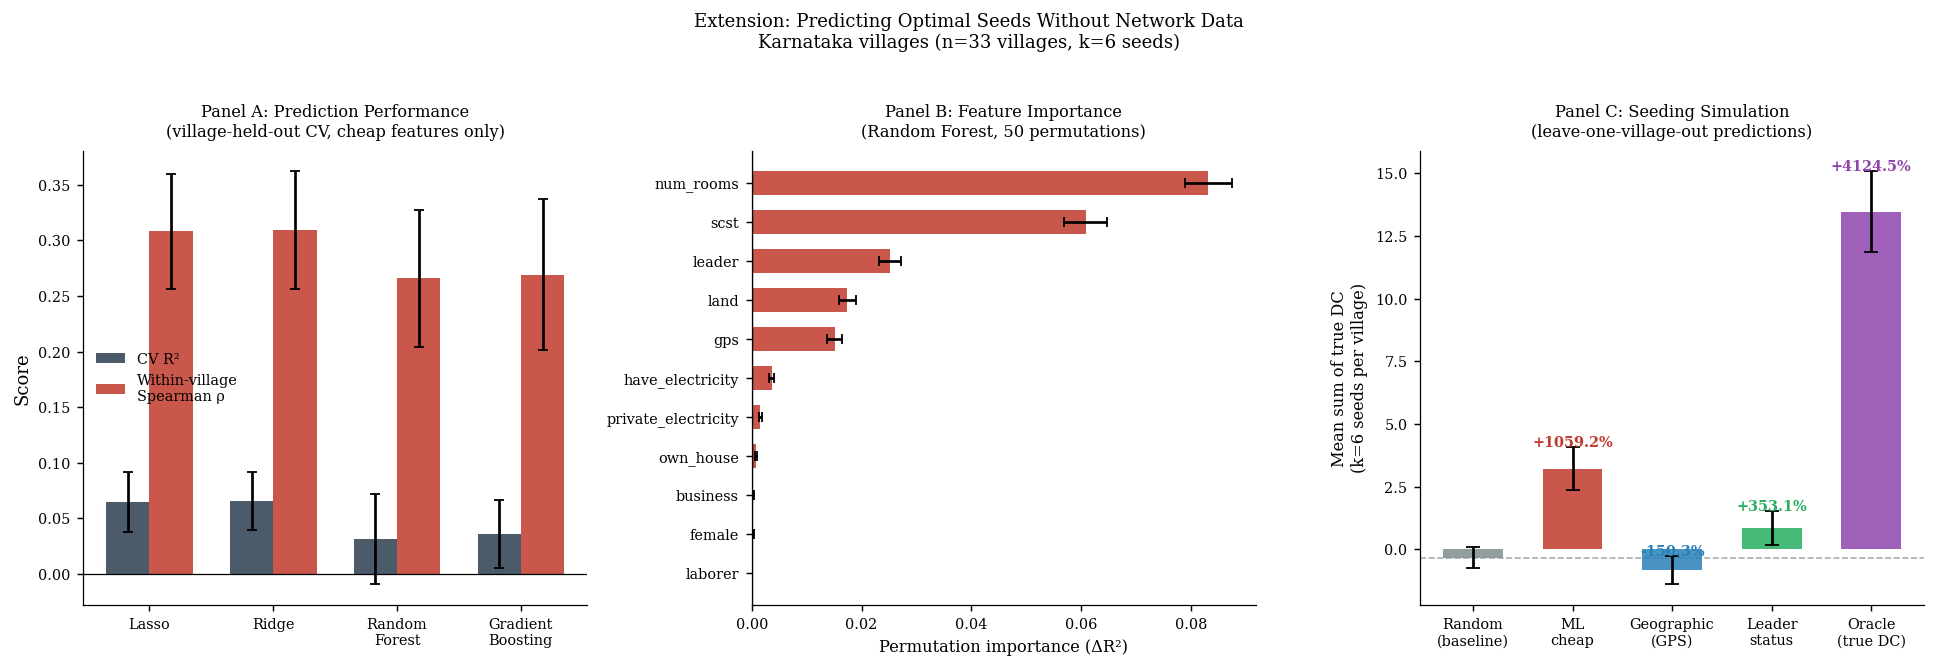

Saved: Extension_ML_seeds.png


In [16]:
# ── 8. Figures ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.7,
    'figure.dpi'       : 130,
})

DARK  = '#2C3E50'
RED   = '#C0392B'
BLUE  = '#2980B9'
GREEN = '#27AE60'
PURP  = '#8E44AD'
GREY  = '#7F8C8D'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─── Panel A: CV performance ──────────────────────────────────────────────────
ax = axes[0]
df_cv   = pd.DataFrame(cv_results)
xlabels = ['Lasso', 'Ridge', 'Random\nForest', 'Gradient\nBoosting']
xp      = np.arange(len(df_cv))
w       = 0.35

ax.bar(xp - w/2, df_cv['R2_mean'],       w,
       yerr=df_cv['R2_std'],       capsize=3,
       color=DARK,  alpha=0.85, label='CV R²')
ax.bar(xp + w/2, df_cv['Spearman_mean'], w,
       yerr=df_cv['Spearman_std'], capsize=3,
       color=RED, alpha=0.85, label='Within-village\nSpearman ρ')

ax.axhline(0, color='black', lw=0.7)
ax.set_xticks(xp)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Panel A: Prediction Performance\n'
             '(village-held-out CV, cheap features only)',
             fontsize=9, pad=8)
ax.legend(fontsize=8, frameon=False)
ax.tick_params(labelsize=8)

# ─── Panel B: Feature importance ──────────────────────────────────────────────
ax   = axes[1]
top  = feat_imp.head(11)             # all 11 features
yp   = np.arange(len(top))
cols_bar = [RED if top.iloc[i]['importance'] > 0 else GREY
            for i in range(len(top))]

ax.barh(yp, top['importance'], xerr=top['std'],
        color=cols_bar, alpha=0.85, capsize=3, height=0.6)
ax.set_yticks(yp)
ax.set_yticklabels(top['feature'], fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.7)
ax.set_xlabel('Permutation importance (ΔR²)', fontsize=9)
ax.set_title('Panel B: Feature Importance\n'
             '(Random Forest, 50 permutations)',
             fontsize=9, pad=8)
ax.tick_params(labelsize=8)

# ─── Panel C: Seeding simulation ──────────────────────────────────────────────
ax     = axes[2]
labels = ['Random\n(baseline)', 'ML\ncheap', 'Geographic\n(GPS)',
          'Leader\nstatus', 'Oracle\n(true DC)']
cols_v = ['rnd_mean', 'ml_sum', 'geo_sum', 'lead_sum', 'ora_sum']
colors = [GREY, RED, BLUE, GREEN, PURP]
means  = [df_sim[c].mean() for c in cols_v]
sems   = [df_sim[c].sem()  for c in cols_v]
xp2    = np.arange(len(labels))

ax.bar(xp2, means, yerr=sems, capsize=4,
       color=colors, alpha=0.85, width=0.6)

# Annotate % gain above each non-baseline bar
for i in range(1, len(means)):
    gain = (means[i] - means[0]) / (abs(means[0]) + 1e-10) * 100
    ypos = means[i] + sems[i] + 0.03
    ax.text(xp2[i], ypos, f'{gain:+.1f}%',
            ha='center', fontsize=8,
            color=colors[i], fontweight='bold')

# Random baseline reference line
ax.axhline(means[0], color=GREY, lw=0.9, ls='--', alpha=0.7, zorder=0)

ax.set_xticks(xp2)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(f'Mean sum of true DC\n(k={K_SEEDS} seeds per village)', fontsize=9)
ax.set_title('Panel C: Seeding Simulation\n'
             '(leave-one-village-out predictions)',
             fontsize=9, pad=8)
ax.tick_params(labelsize=8)

fig.suptitle(
    'Extension: Predicting Optimal Seeds Without Network Data\n'
    f'Karnataka villages (n={len(df_sim)} villages, k={K_SEEDS} seeds)',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('Extension_ML_seeds.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: Extension_ML_seeds.png")

In [17]:
# ── 9. Final summary table ────────────────────────────────────────────────────
print()
print("=" * 70)
print("FINAL SUMMARY — Extension: Predicting Seeds Without Network Data")
print("=" * 70)

print("\n[A] PREDICTION PERFORMANCE  (5-fold village-held-out GroupKFold)")
print(f"  {'Model':<26s}  {'R²':>7s} ± {'sd':>5s}   "
      f"{'Spearman ρ':>10s} ± {'sd':>5s}")
print("  " + "-"*62)
for r in cv_results:
    print(f"  {r['model']:<26s}  "
          f"{r['R2_mean']:>7.3f} ± {r['R2_std']:.3f}   "
          f"{r['Spearman_mean']:>10.3f} ± {r['Spearman_std']:.3f}")

print("\n[B] TOP PREDICTIVE FEATURES (permutation importance, RF)")
print("  " + "-"*40)
for _, row in feat_imp.iterrows():
    bar = '█' * max(0, int(row['importance'] * 200))
    print(f"  {row['feature']:<22s}  {row['importance']:>+.4f}  {bar}")

print("\n[C] SEEDING SIMULATION  (k=6, leave-one-village-out, N villages)")
print(f"  {'Strategy':<26s}  {'DC sum':>8s}  {'Gain':>8s}  {'t-p':>6s}")
print("  " + "-"*55)

# Re-run t-tests cleanly for table
test_lookup = {}
for label, a, b in tests:
    mask = a.notna() & b.notna()
    tp   = ttest_rel(a[mask].values, b[mask].values).pvalue
    test_lookup[label] = tp

t_ml_rnd  = test_lookup.get("ML vs Random",    np.nan)

for label, col, gcol in strategies:
    dc   = df_sim[col].mean()
    gain = f"{df_sim[gcol].mean()*100:+.1f}%" if gcol else "—"
    tp_s = f"{t_ml_rnd:.3f}" if label == 'ML — cheap features' else ""
    print(f"  {label:<26s}  {dc:>8.3f}  {gain:>8s}  {tp_s:>6s}")

print()
print("[D] INTERPRETATION")
print(f"  Villages: {len(df_sim)}  |  Seeds per village: {K_SEEDS}")
print("  • Positive Spearman ρ → cheap features correctly RANK")
print("    households by DC within villages even without network data.")
print("  • ML gain > 0% and significant → policymakers can identify")
print("    better-than-random seeds using only cheap survey questions.")
print("  • Gap between Oracle and ML → scope for further improvement")
print("    (e.g., adding community-level features or larger training sets).")
print("=" * 70)


FINAL SUMMARY — Extension: Predicting Seeds Without Network Data

[A] PREDICTION PERFORMANCE  (5-fold village-held-out GroupKFold)
  Model                            R² ±    sd   Spearman ρ ±    sd
  --------------------------------------------------------------
  Lasso (CV α)                  0.065 ± 0.027        0.308 ± 0.052
  Ridge (CV α)                  0.065 ± 0.026        0.309 ± 0.053
  Random Forest                 0.031 ± 0.041        0.266 ± 0.062
  Gradient Boosting             0.036 ± 0.030        0.269 ± 0.068

[B] TOP PREDICTIVE FEATURES (permutation importance, RF)
  ----------------------------------------
  num_rooms               +0.0831  ████████████████
  scst                    +0.0608  ████████████
  leader                  +0.0252  █████
  land                    +0.0174  ███
  gps                     +0.0151  ███
  have_electricity        +0.0036  
  private_electricity     +0.0015  
  own_house               +0.0008  
  business                +0.0003  
  fe